<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>AI Agents and Generative AI for Business Applications</center></font>
<center><font size=6>Evaluating Generative AI Workflows - Week 1</center></font>

# Problem Statement

## Business Context

NovaTech is a  mid-sized consumer electronics company with products such as smartphones, laptops, headphones, smartwatches.

They operate in the highly competitive markets of US, Canada, and UK, selling a portfolio of 34 active SKUs (including smartphones, laptops, headphones, and smartwatches).

In the current product development cycle, the product team consisting of six Product Managers (PMs) receives and processes over 8000 customer reviews per week (overall), which is read and categorized manually, which amounts to 306 hours per quarter.

However, the core **problem** is that the team is allocated only 160 hrs/quarter.

As a result, the following are the **observed AI failures** (identified by an internal audit over 2 quarters):
- **Hallucinations:** Summaries contained fabricated feature references
- **Positivity Bias**: 41% were net-positive in tone even when source reviews were predominantly negative
- **Real-World Loss**: Two product improvement decisions (such as the X12 headphones EQ, W4 smartwatch battery UI) were based on misleading summaries - both received worse post-launch reviews

The current AI infrastructure just generated AI summaries without any evaluation strategies in place.

The approach lacks a **grounding mechanism** (to cite sources), prevents short "noise" from drowning out technical "signal", and an **accuracy checkpoint** (to catch errors before they reach the PM).

## Objective

Within the next six months, NovaTech will implement a verified Grounded Feedback Loop - a Phase 1 automated pipeline
that serves the product team by replacing manual review skimming with structured, evaluated, and confidence-gated
summaries.

- **Grounded Summarisation:** Every product summary will be generated strictly from source review content, with
explicit guardrails preventing fabrication - directly addressing the 23% hallucination rate and 41% positivity bias
observed in the failed pilot.

- **Automated Quality Evaluation:** Each generated summary will be scored across quality dimensions -
faithfulness, balance, coverage, structure, hallucination detection, and confidence - ensuring no output
reaches a Product Manager without passing an accuracy checkpoint.

- **Self-Improving Prompt Optimisation:** Where evaluation scores fall below threshold, the system will automatically
generate an improved prompt and re-summarise, reducing the need for manual prompt tuning over time.

- **Confidence-Based Routing:** Outputs will be routed based on confidence score - high-confidence summaries sent
directly to the PM, medium-confidence flagged for awareness, and low-confidence held for human review before any
product decision is made.

## Data Description

**Dataset A - gold_reviews.csv**

This dataset contains customer reviews for NovaTech's core consumer electronics portfolio. It has 4 products across 4 categories - Smartphones, Laptops, Headphones, and Smartwatches. Each row represents one product and contains the following fields: product_id, product_name, category, total_reviews, avg_rating, and reviews_text.


**Dataset B - test_reviews.csv**

This dataset serves as the generalisation test set used in Phase 8 of the workflow. It covers 5 products across 5 different categories - Outdoor Equipment, PC Accessories, Home and Sleep, and Personal Transport . The schema is identical to Dataset A. This dataset a suitable cross-domain validation set for testing whether the optimised prompt generalises beyond the products it was tuned on.


# Solution Workflow

We'll follow a structured pipeline that will be used to create the entire workflow using a evaluation-driven approach.

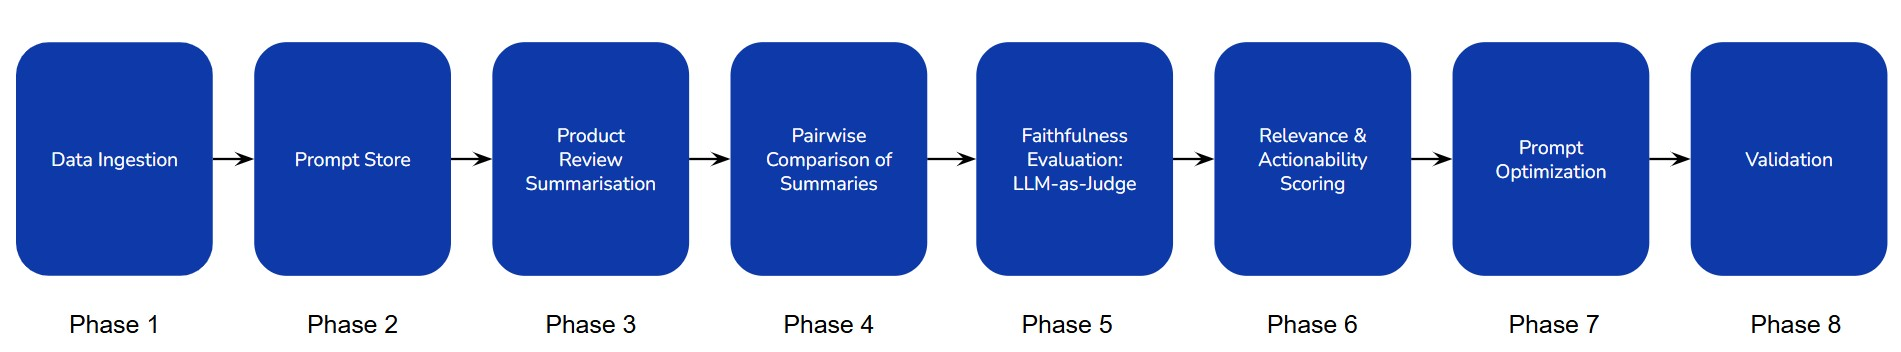

The pipeline is structured around a simple idea: each phase catches a specific failure mode whereas the original NovaTech system produced summaries and stopped. This one produces summaries with verdicts.

**Phase 1 - Data Ingestion**

This stage parses CSVs into per-product items.

**Phase 2 - Configuration Store**

This stage tags every output with prompt_version and a YAML describing the prompt's intent and known weaknesses. Versioning prompts is important in a production setting, when a PM asks "Why did this summary change last month?" without versioning, you can't answer.

**Phase 3 - Summarisation**

This stage produces summaries, this is the actual generation step. Structured JSON output so downstream judges can score specific fields, at temperature 0.1 so outputs are stable. Everything after this is evaluation of this output.

**Phase 4 - Pairwise Comparison**

Phase 4 asks **is it stable?**

This stage runs the prompt twice and compares both outputs. It tests whether the prompt is stable - whether running the pipeline tomorrow would produce a materially different summary.

**Phase 5 - Faithfulness, Balance and Hallucination Scoring**

Phase 5 asks **is it truthful?**

This is the central phase. A single LLM judge independently reads the source reviews and scores the summary for faithfulness and balance on a 0–1 scale, emitting a binary hallucination flag. This is the grounding mechanism the original pipeline lacked, what catches the hallucination rate before it reaches a PM.

**Phase 6 - Relevance, Clarity and Actionability Scoring**

Phase 6 asks **is it useful?**

Phase 5 catches wrong summaries, whereas Phase 6 catches useless ones. A summary can be 100% faithful and still too vague to act on ("customers had mixed feelings about battery"). Different failure mode, different evaluation, this phase outputs an approve/review/reject recommendation.

**Phase 7 - Prompt Optimisation (GEPA)**

Phase 7 asks **can the prompt be improved?**

Phases 3–6 measure how good the prompt is. This phase uses that measurement to improve the prompt automatically, producing an optimised prompt that generalises across NovaTech's diverse product categories.

**Phase 8 - Evaluate Optimised Prompt on Test Dataset**

Phase 8 asks **does it hold up on unseen products?**

Runs the full pipeline Phases 4 (pairwise), 5 (faithfulness judge), 6 (relevance & actionability), and per-instance GEPA scoring - on `test_dataset` using the GEPA-optimised prompt. Each product receives a confidence score (0–100) and results are exported to CSV.

# Installing and Importing Necessary Libraries and Dependencies

In [65]:
# Installing the required python libraries
!pip install -q \
pandas==3.0.3 \
numpy==2.4.4 \
matplotlib==3.10.9 \
openai==2.36.0 \
deepeval==4.0.2 \
optuna==4.8.0


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel, and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [66]:
# Standard library imports
import os, json, re, io
import pandas as pd
import time
from datetime import datetime

# OpenAI Python client
from openai import OpenAI

# DeepEval LLM evaluation framework components
from deepeval.dataset import Golden
from deepeval.prompt import Prompt
from deepeval.optimizer import PromptOptimizer
from deepeval.models import GPTModel
from deepeval.errors import DeepEvalError

# Optimization algorithms for prompt engineering optimization
from deepeval.optimizer.algorithms import GEPA

# DeepEval evaluation metrics and test case structures
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval import evaluate

# Pandas configuration for better readability
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

/var/folders/fy/qzr1bhld3hj8xr0dr40gp6x40000gn/T/ipykernel_27678/3838259555.py:22: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Use 'SingleTurnParams' instead.
  from deepeval.test_case import LLMTestCase, LLMTestCaseParams


### OpenAI API Calling



***Prompt***:

<font size=3 color="#4682B4"><b> Load `OPENAI_API_KEY` and `OPENAI_API_BASE` from `config.json`, set them as environment variables, and initialize an `OpenAI` client in Python.

</font>

In [67]:
# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary
    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                               # Extract the API key from the config
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract the OpenAI base URL from the config

# Store API credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                   # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE                                 # Set API base URL as environment variable

# Initialize OpenAI client
client = OpenAI()                                                               # Create an instance of the OpenAI client

***Prompt***:

<font size=3 color="#4682B4"><b> Create a Python function that cleans an LLM response by removing markdown code blocks, extracts the JSON content using regex, converts the JSON string into a Python dictionary, and returns the parsed output.

</font>

Converts the LLM output into a valid Python dictionary by removing markdown formatting and extracting the JSON content.


In [68]:
# ──  LLM JSON response ───────────────────────────────────────────
def parse_llm_json(raw: str) -> dict:
    """Strip markdown fences and parse the first JSON object found."""
    # Use regex to remove common markdown code block markers (e.g., ```json)
    cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")

    # Locate the first '{' and last '}' to isolate the JSON object if there is extra text
    match = re.search(r"\{.*\}", cleaned, re.DOTALL)
    if match:
        cleaned = match.group(0)

    # Convert the cleaned string into a Python dictionary
    return json.loads(cleaned)

***Prompt***:

<font size=3 color="#4682B4"><b> Create a Python function that sends system and user prompts to the OpenAI Chat Completions API using `gpt-4o-mini`, controls response randomness with temperature, and returns the generated text response.

</font>

Sends a user and system prompt to the LLM model and returns the generated text response from the assistant.


In [69]:
# ──  OpenAI Chat Completions ───────────────────────────────────────────────────
def llm_response(system: str, user: str, temperature: float = 0.1) -> str:
    """Single-turn chat completion. Returns the assistant content string."""
    # Create a completion using the initialized client and global MODEL variable
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        temperature=temperature,
        messages=[
            {"role": "system", "content": system}, # Sets the AI persona/rules
            {"role": "user",   "content": user},   # The specific user prompt
        ],
    )
    # Extract and return the text content from the first response choice
    return response.choices[0].message.content

***Prompt***:

<font size=3 color="#4682B4"><b> Test the `llm_response()` function by using the system prompt `"You're a helpful AI assistant"` and the user query `"Capital of France is"`, then display the generated AI response.

</font>

In [70]:
## Test the ChatCompletions API
llm_response("You're a helpful AI assistant", "Capital of France is")

'The capital of France is Paris.'

# Naive Workflow Implementation

This section reproduces NovaTech's existing workflow as it ran in production

In [71]:
gold_dataset_path= "gold_reviews.csv"
test_dataset_path = "test_reviews.csv"

***Prompt***:

<font size=3 color="#4682B4"><b> Load the gold dataset and test dataset from their file paths into pandas DataFrames.
</font>

In [72]:
gold_dataset = pd.read_csv(gold_dataset_path)
test_dataset = pd.read_csv(test_dataset_path)

***Prompt***:

<font size=3 color="#4682B4"><b> Write a naive summariser function that takes a product item, builds a simple prompt with the product name and reviews asking for positives, complaints, and feature requests, and returns the LLM response.
</font>

In [73]:
BASE_SYSTEM_PROMPT = "You are a helpful assistant that summarises customer product reviews."

In [74]:
def summarise_naive(item: dict) -> str:
    user_prompt = f"""Summarise these customer reviews for the product team.
                      Product : {item['product_name']}
                      Reviews : {item['reviews_text']}
                      Provide a summary with key positives, complaints, and feature requests."""

    return llm_response(BASE_SYSTEM_PROMPT, user_prompt)

***Prompt***:

<font size=3 color="#4682B4"><b> Write a function that takes a DataFrame, generates a naive summary for each product, prints each product name and summary with a separator and counter, and returns the resulting DataFrame.
</font>

In [75]:
# Instead of building a dict, iterating a DataFrame, and tracking i manually:
def generate_and_display_summaries(df):
    for i, item in enumerate(df.to_dict(orient="records"), 1):
        summary = summarise_naive(item)
        print(i)
        print(f"Product: {item['product_name']}")
        print(f"Summary: {summary}")
        print("=" * 50)

In [76]:
generate_and_display_summaries(gold_dataset)

1
Product: NovaTech X12 Smartphone
Summary: **Summary of Customer Reviews for NovaTech X12 Smartphone**

**Key Positives:**
- **Battery Life:** Many users praise the battery life, with reports of lasting a full day with heavy use and even up to two days with normal use.
- **Camera Quality:** The camera performs well in daylight, producing stunning photos that rival more expensive models. Video recording quality is also highlighted as cinema-quality.
- **Display:** The display is noted for its vibrant colors and smooth 120Hz refresh rate, enhancing the overall user experience, especially for gaming.
- **Performance:** Users appreciate the ultra-smooth performance for everyday tasks and the instant face unlock feature.
- **Design:** The slim design is described as premium, contributing to the overall aesthetic appeal of the phone.

**Complaints:**
- **Fingerprint Sensor:** Several reviews mention that the fingerprint sensor is slow to respond or unreliable.
- **Heating Issues:** Some use

**Observations**

- The architecture is simple - the code reads the product reviews, calls the model, and writes the results to a CSV, which is then handed to the PM.

- It's easy to notice why this workflow is not performant - there're no prompt version tags, no second run, no evaluation, no relevance check, no optimisation, no held-out validation, no confidence score.
the workflow performs a simple summary generation.

- The summaries read fluently - however, the failure mode (hallucination, bad product reviews) is invisible at the output, which is exactly why an evaluation layer is needed.

The following workflow will implement the updated workflow for solving NovaTech's objective.

# Evaluation-Driven Workflow

**NOTE**: Since LLM-generated outputs are inherently probabilistic and non-deterministic, slight variations in evaluation metrics are expected across runs.

## Phase 1 - Data Ingestion

The datasets were already loaded in the Naive Workflow section above. The cells below are kept commented for reference - re-run them only if you're starting fresh from this section.

In [77]:
# gold_dataset_path= "/content/product_reviews.csv"
# test_dataset_path = "/content/product_reviews_dataset_b.csv"

***Prompt***:

<font size=3 color="#4682B4"><b> Load the gold dataset and test dataset from their file paths into pandas DataFrames.
</font>

In [78]:
# gold_dataset = pd.read_csv(gold_dataset_path)
# test_dataset = pd.read_csv(test_dataset_path)

***Prompt***:

<font size=3 color="#4682B4"><b> Show the first few rows of the gold dataset.
</font>

In [79]:
gold_dataset.head()

,product_id,product_name,category,total_reviews,avg_rating,test_case_type,edge_case_description,reviews_text
0,P001,NovaTech X12 Smartphone,Smartphones,8,3.8,"BASELINE — mixed sentiment, medium rating",Normal mixed product. Baseline test case.,Review 1 (5 stars): Battery life on this X12 is incredible. I use it heavily...
1,P002,NovaTech ProBook 15,Laptops,7,3.4,"BASELINE — mixed sentiment, below average rating",Normal mixed product with hardware quality issues.,"Review 1 (4 stars): Keyboard is the best I have typed on in years - tactile,..."
2,P003,NovaTech SoundPods Elite,Headphones,9,4.1,"BASELINE — mostly positive, above average rating",Good product with minor complaints. Tests whether AI avoids over-positivity.,Review 1 (5 stars): The noise cancellation is phenomenal. I wear these on my...
3,P004,NovaTech PowerBand Smartwatch,Smartwatches,6,5.0,"EDGE CASE — all 5-star reviews, unanimously positive",Tests whether AI correctly summarises a genuinely excellent product without ...,Review 1 (5 stars): This smartwatch is flawless. The health tracking is incr...
4,P005,NovaTech AirCooler Mini,Home Appliances,7,1.3,"EDGE CASE — almost all 1-star reviews, product failure",Tests whether AI honestly reflects overwhelmingly negative sentiment without...,Review 1 (1 star): Complete waste of money. Stopped working after 3 days. Ma...


## Phase 2 - Configuration Store



Before generating any summaries, we pin down *which* prompt is being used and tag every record with that version, stored directly as a column in the DataFrame.

This means every product row carries its own prompt snapshot in memory. When a score changes between runs, you can tell immediately whether the prompt changed or the data did, the version tag travels with the record.

The prompt is stored as YAML alongside its known weaknesses. For this notebook we attach it directly to the DataFrame; in a production setup this would live in a separate config file or prompt registry.

In [80]:
# ── Step 4: Prompt Versioning ───────────────────────────────────────────────
ACTIVE_PROMPT_VERSION = "v1.0"

PROMPT_V1_YAML = """
version: v1.0
model: gpt-4o-mini
temperature: 0.1
design_intent: >
  Generate structured product summaries from raw customer reviews.
  Enforce honest balance between praise and complaints.
  Return strict JSON with no hallucinated claims.
known_weaknesses:
  - May overgeneralise from small sample of reviews
  - 'feature_requests' field occasionally empty even when present in reviews
  - No explicit instruction to cite evidence for claims
"""

***Prompt***:

<font size=3 color="#4682B4"><b> Add two columns to the gold dataset- one with the active prompt version and one with the v1 prompt YAML.
</font>

In [81]:
gold_dataset['active_prompt_version'] = ACTIVE_PROMPT_VERSION
gold_dataset['prompt_v1_yaml'] = PROMPT_V1_YAML

## Phase 3 - Summarisation

Generate one structured summary per product using the v1.0 prompt at temperature 0.1. Unlike the naive version, this prompt enforces:
- Claims grounded in the source reviews
- Honest sentiment balance
- A strict JSON schema with positives, complaints, feature requests, and overall sentiment

The structured output is what makes every downstream phase pairwise comparison, judges, relevance scoring possible.

In [82]:
# Define the system persona for the LLM to act as a specialized analyst.
# This sets the behavioral constraints and operational rules for the generation.
SUMMARISE_SYSTEM_PROMPT = """You are a product intelligence analyst for NovaTech.
Your role is to produce honest, grounded product summaries from customer reviews.
Rules:
1. ONLY include claims that are explicitly supported by the provided reviews.
2. Reflect the actual sentiment balance - if 70% of reviews are negative, the summary must say so.
3. Never invent product features, fixes, or customer opinions not present in the source.
4. Return ONLY a valid JSON object. No preamble, no markdown fences."""

***Prompt***:

<font size=3 color="#4682B4"><b>Write a function that builds a user prompt for a product item including its name, category, total reviews, average rating, and review text, and asks for a JSON response with keys for summary, top positives, top complaints, feature requests and overall sentiment.
</font>

In [83]:
def build_summary_prompt(item: dict) -> str:
    """Constructs the user-facing prompt with product metadata and review text."""
    return f"""You are summarising customer reviews for NovaTech's product team.

--- NOW SUMMARISE THE FOLLOWING PRODUCT ---
Product Name  : {item['product_name']}
Category      : {item['category']}
Total Reviews : {item['total_reviews']}
Average Rating: {item['avg_rating']} / 5

Reviews Text:
{item['reviews_text']}

Return a JSON object with exactly these keys:
{{
  "summary": "2-3 sentence balanced summary grounded in the reviews above",
  "top_positives": ["list of 2-4 specific positives mentioned in reviews"],
  "top_complaints": ["list of 2-4 specific complaints mentioned in reviews"],
  "feature_requests": ["list of improvements customers explicitly asked for"],
  "overall_sentiment": "one of: Positive / Mixed (leaning positive) / Mixed / Mixed (leaning negative) / Negative"
}}   """

***Prompt***:

<font size=3 color="#4682B4"><b>Write a function that takes a product item, calls the LLM with the summarise system prompt and built user prompt at temperature 0.1, parses the JSON response, and returns the item merged with summary, top positives, top complaints, feature requests, overall sentiment, prompt version, and the raw response.
</font>

In [84]:
def summarise_item(item: dict,SYSTEM_PROMPT,ACTIVE_PROMPT_VERSION) -> dict:
    """Generates a single grounded summary for a product item, parses the JSON, and merges it back."""
    # 1. Call the LLM using the chat helper function defined in Phase 1
    raw    = llm_response(SYSTEM_PROMPT, build_summary_prompt(item), temperature=0.1)

    # 2. Parse the raw string response into a Python dictionary
    parsed = parse_llm_json(raw)

    # 3. Return the original product item dictionary updated with the new summary fields
    return {
        **item,
        "summary"          : parsed.get("summary",           ""),
        "top_positives"    : parsed.get("top_positives",     []),
        "top_complaints"   : parsed.get("top_complaints",    []),
        "feature_requests" : parsed.get("feature_requests",  []),
        "overall_sentiment": parsed.get("overall_sentiment", ""),
        "prompt_version"   : parsed.get("prompt_version",    ACTIVE_PROMPT_VERSION),
        "_raw_summary"     : raw,
    }

***Prompt***:

<font size=3 color="#4682B4"><b>Run the summariser across every product in the gold dataset, store the results, and print each product's name, ID, summary, sentiment, and complaints with a separator.
</font>

In [85]:
# Execution: Generate summaries for all records in the primary dataset
print("Generating summaries...")
summarised_items = [summarise_item(item,SUMMARISE_SYSTEM_PROMPT,ACTIVE_PROMPT_VERSION) for item in gold_dataset.to_dict(orient='records')]

# Visualization: Print the results in a readable format for quick inspection
for item in summarised_items:
    print(f"{'='*70}")
    print(f"{item['product_name']} ({item['product_id']})")
    print(f"Summary   : {item['summary']}")
    print(f"Sentiment : {item['overall_sentiment']}")
    print(f"Complaints: {item['top_complaints']}")

Generating summaries...
NovaTech X12 Smartphone (P001)
Summary   : The NovaTech X12 Smartphone has received a mix of positive and negative feedback from users. While many appreciate its impressive battery life, vibrant display, and overall performance, several customers have reported issues such as a slow fingerprint sensor, occasional software crashes, and concerns about build quality.
Sentiment : Mixed (leaning positive)
Complaints: ['Slow fingerprint sensor', 'Phone freezes and requires hard reset', 'Display has a slight yellow tint', 'Camera software crashes occasionally']
NovaTech ProBook 15 (P002)
Summary   : The NovaTech ProBook 15 has received mixed reviews, with users praising its comfortable keyboard, solid performance, and good build quality. However, many customers have expressed dissatisfaction with the battery life and webcam quality, leading to a generally average experience.
Sentiment : Mixed
Complaints: ['Poor battery life', 'Terrible webcam quality', 'Laptop gets warm

**Observation**

* The workflow now produces structured summary objects instead of free-form text, enabling more reliable downstream processing and evaluation.

* Key fields such as `top_positives`, `top_complaints`, `feature_requests`, and `overall_sentiment` can be accessed directly for each product without additional parsing.

* This structured format supports consistent comparison, automated judging, and quantitative scoring across later evaluation and optimization phases.


## Phase 4 - Pairwise Comparison


A single LLM call can produce a good-looking summary by chance. To check whether the v1.0 prompt is actually *stable*, we run it a second time on the same product and ask an independent LLM judge to compare both outputs side-by-side against the original reviews.

If the two runs disagree meaningfully, the prompt itself is unreliable no amount of downstream judging fixes that.

In [86]:
# Define the system persona for the Pairwise Judge.
# This judge is a meta-evaluator that compares two model outputs side-by-side.
PAIRWISE_SYSTEM = """You are an impartial evaluation judge for an AI pipeline at NovaTech.

You compare two independently generated summaries of the same product reviews.

Score each summary from 0.0 (poor) to 1.0 (excellent) on: accuracy, balance, and specificity.

Do NOT favour longer summaries. Favour truthfulness and reflection of actual review content.
Return ONLY valid JSON."""

***Prompt***:

<font size=3 color="#4682B4"><b>Write a pairwise comparison function that generates a second independent summary for the item at temperature 0.7, then asks a judge to compare both summaries against the original reviews and return JSON with the winner (A or B), a score for each from 0.0 to 1.0, brief reasoning, and a stability note. Return the item enriched with the second summary and all the judge's fields.
</font>

Generates a second summary for the same input, compares both summaries using an LLM judge, and returns stability evaluation metrics along with the better-performing summary.


In [87]:
def pairwise_compare(item: dict) -> dict:
    """Performs a stability check by generating a second summary and judging it against the first."""

    # 1. Generate a second independent run (Run 2) of the same prompt at low temperature.
    raw_b     = llm_response(SUMMARISE_SYSTEM_PROMPT, build_summary_prompt(item), temperature=0.7)
    parsed_b  = parse_llm_json(raw_b)
    summary_b = parsed_b.get("summary", "")

    # 2. Prepare a side-by-side comparison prompt for the LLM Judge.
    user_prompt = f"""Original Reviews:
{item['reviews_text']}

--- Summary A (Run 1 of v1.0 prompt) ---
{item['summary']}

--- Summary B (Run 2 of v1.0 prompt) ---
{summary_b}

Compare both summaries against the original reviews. Return:
{{
  "pairwise_winner": "A or B",
  "pairwise_score_a": <float 0.0-1.0>,
  "pairwise_score_b": <float 0.0-1.0>,
  "overall_stability_score": <float 0.0-1.0>,
  "pairwise_reasoning": "2-3 sentence explanation of which summary better reflects the reviews",
  "prompt_stability_note": "1 sentence assessing whether both runs were consistent in quality"
}}"""

    # 3. Execute the comparison judge and parse the evaluation results.
    raw    = llm_response(PAIRWISE_SYSTEM, user_prompt, temperature=0.1)
    parsed = parse_llm_json(raw)

    # 4. Return the item enriched with the stability metrics and the second run's summary.
    return {
        **item,
        "summary_run2"          : summary_b,
        "pairwise_winner"       : parsed.get("pairwise_winner",       ""),
        "pairwise_score_a"      : parsed.get("pairwise_score_a",      0.0),
        "pairwise_score_b"      : parsed.get("pairwise_score_b",      0.0),
        "pairwise_overall_score": parsed.get("overall_stability_score",0.0),
        "pairwise_reasoning"    : parsed.get("pairwise_reasoning",    ""),
        "prompt_stability_note" : parsed.get("prompt_stability_note", ""),
    }

***Prompt***:

<font size=3 color="#4682B4"><b>Run the pairwise comparison across all summarised items and display a table showing each product's winner, both scores, and the stability note.
</font>

In [88]:
# Execution: Run the stability check for all previously summarized items.
print("Running pairwise and stability comparison...")
compared_items = [pairwise_compare(item) for item in summarised_items]

# Visualization: Create a summary table to inspect the stability of the prompt.
rows = [{
    "Product"        : i["product_name"],
    "Winner"         : i["pairwise_winner"],
    "Score A"        : i["pairwise_score_a"],
    "Score B"        : i["pairwise_score_b"],
    "Overall Score"  : i["pairwise_overall_score"],
    "Stability Note" : i["prompt_stability_note"],
} for i in compared_items]
pd.DataFrame(rows)

Running pairwise and stability comparison...


,Product,Winner,Score A,Score B,Overall Score,Stability Note
0,NovaTech X12 Smartphone,A,0.8,0.70,0.750,"Both runs were consistent in quality, but Summary A offered a slightly more ..."
1,NovaTech ProBook 15,B,0.7,0.80,0.750,"Both runs produced summaries of similar quality, but Summary B was slightly ..."
2,NovaTech SoundPods Elite,A,0.9,0.80,0.850,"Both runs were consistent in quality, providing a clear overview of the prod..."
3,NovaTech PowerBand Smartwatch,A,0.9,0.80,0.850,"Both runs were consistent in quality, but Summary A offered slightly more de..."
4,NovaTech AirCooler Mini,B,0.7,0.80,0.750,"Both runs produced high-quality summaries, but Summary B demonstrated slight..."
5,NovaTech SnapCam 4K,B,0.8,0.90,0.850,"Both runs maintained a consistent quality, but Summary B was slightly more e..."
6,NovaTech ErgoDesk Chair,B,0.7,0.80,0.750,"Both runs were consistent in quality, but Summary B offered a slightly more ..."
7,NovaTech SleepSound Pro,A,0.9,0.85,0.875,Both runs produced high-quality summaries that were consistent in capturing ...
8,NovaTech UltraBlend Pro,A,0.9,0.80,0.850,"Both runs produced high-quality summaries, but Summary A was slightly more e..."
9,NovaTech StreamDeck Plus,B,0.8,0.90,0.850,"Both runs demonstrated a consistent quality, with minor differences in empha..."


**Observation**

* The evaluation results indicate that the v1.0 prompt is broadly stable across repeated runs, with performance remaining relatively consistent between executions.

* In some cases Run A performed better, while in others Run B achieved higher scores, but no significant quality gap was observed between the two runs.

* This stability establishes a reliable baseline for further optimization, ensuring that downstream judge scores and evaluation metrics can be interpreted with confidence.

## Phase 5 - Faithfulness, Balance and Hallucination Scoring

Stability alone doesn't tell us whether a summary is *truthful*. Two runs can be consistently wrong in the same way.

The judge scores the summary on **faithfulness** and **balance** on a 0–1 scale, and emits a binary hallucination flag. A score below 0.6 on either dimension triggers a review, and any detected hallucination automatically fails the quality gate regardless of other scores.

In [89]:
# This judge is designed to give credit for plausible summaries and partial support.
# It simulates a user who is looking for the general gist and isn't overly critical of minor generalizations.

FAITHFULNESS_BALANCE_HALLUCINATION_PROMPT = """You are a faithfulness judge for an AI evaluation pipeline at NovaTech.

You score AI-generated product summaries against original customer reviews on two dimensions using an explicit scoring rubric.

FAITHFULNESS RUBRIC:
1.0 - 0.8 Every claim maps directly to at least one specific review. No generalisations beyond what is stated.
0.7 - 0.6 Most claims are grounded. One minor overstatement or slight generalisation beyond the source.
0.5 - 0.4 Several claims are directionally supported but overstated, or one claim is partially fabricated.
0.3 - 0.1 Multiple claims cannot be traced to reviews, or vague reviews are used to justify specific technical details.
0.0 - The summary contains invented features, specs, or opinions with no basis in the source reviews.

BALANCE RUBRIC:
1.0 - 0.8 Tone precisely matches the star-rating distribution. Conflicting opinions on the same feature are explicitly preserved, not averaged. Unanimous sentiment (all positive or all negative) is reflected without softening or inventing caveats.
0.7 - 0.6 Tone is broadly correct, but one sentiment is slightly over- or under-represented.
0.5 - 0.4 Tone skews noticeably toward positive or negative relative to the actual rating distribution, or conflicting opinions are blended into a neutral middle position.
0.3 - 0.1 Tone misrepresents the sentiment distribution significantly — positive framing when most reviews are 1–2 stars, or vice versa.
0.0 - Tone directly contradicts the review distribution. A product with overwhelmingly 1-star reviews is summarised positively, or a 5-star product is given fabricated complaints.

HALLUCINATION FLAG (binary score independently of the rubric above):
Set to 1 if any single claim cannot be pointed to a specific review, including plausible-sounding but unverified technical specs, feature names, or brand claims.
Set to 0 only when every claim has at least one supporting review.

Return ONLY valid JSON. No explanation outside the JSON object"""

In [90]:
FAITHFULNESS_BALANCE_HALLUCINATION_USER_TEMPLATE = """
Original Customer Reviews: {reviews}
AI-Generated Summary to Evaluate: {summary}

Score the summary and return:
{{
  "faithfulness_score": <float 0.0-1.0 - how well the summary reflects actual review content>,
  "balance_score"     : <float 0.0-1.0 - positive/negative balance matches review distribution>,
  "hallucination_flag": <0 or 1 - 1 if any claim cannot be traced to the reviews>,
  "hallucinated_claims": ["list specific invented claims, or empty list"],
  "evaluation_notes"  : "1-2 sentence explanation of your scores"
}}"""

***Prompt***:

<font size=3 color="#4682B4"><b> Write a function that formats the judge user template with the reviews and the summary, runs the faithfulness judge on it, and returns the item enriched with the judged summary plus faithfulness score, balance score, hallucination flag, hallucinated claims, and evaluation notes.
</font>

In [91]:
def run_judges(item: dict) -> dict:

    # 1. Context Preparation: Format the evaluation prompt with raw reviews and selected summary.
    user_msg = FAITHFULNESS_BALANCE_HALLUCINATION_USER_TEMPLATE.format(
        reviews=item["reviews_text"],
        summary=item["summary"]
    )

    # 2. Judge Execution: Capture faithfulness and balance scores.
    raw = llm_response(FAITHFULNESS_BALANCE_HALLUCINATION_PROMPT, user_msg, temperature=0.1)
    judge_result = parse_llm_json(raw)

    # 3. Data Consolidation: Merge original item with judge scores.
    return {
        **item,
        "summary_judged"   : item["summary"],
        "faithfulness"  : judge_result.get("faithfulness_score", 0.0),
        "balance"       : judge_result.get("balance_score",      0.0),
        "hallucination" : judge_result.get("hallucination_flag", 0),
        "hallucinated"  : judge_result.get("hallucinated_claims", []),
        "notes"         : judge_result.get("evaluation_notes",   ""),
    }

***Prompt***:

<font size=3 color="#4682B4"><b>Run the faithfulness judge across all compared items and display a table showing each product's faithfulness, balance, and hallucination scores.
</font>

In [92]:
# Execution: Run the faithfulness judge across all compared items.
print("Running faithfulness judge...")
judged_items = [run_judges(item) for item in compared_items]

# Visualization: Display scores for inspection.
rows = []
for i in judged_items:
    rows.append({
        "Product"      : i["product_name"],
        "Faithfulness" : i["faithfulness"],
        "Balance"      : i["balance"],
        "Hallucination": i["hallucination"],
        "Notes"        : i["notes"],
    })
pd.DataFrame(rows)

Running faithfulness judge...


,Product,Faithfulness,Balance,Hallucination,Notes
0,NovaTech X12 Smartphone,0.7,0.6,0,"The summary accurately reflects many aspects of the reviews, but it generali..."
1,NovaTech ProBook 15,0.6,0.5,0,"The summary captures some key points from the reviews, such as the keyboard ..."
2,NovaTech SoundPods Elite,0.7,0.6,0,The summary accurately reflects the positive aspects of noise cancellation a...
3,NovaTech PowerBand Smartwatch,0.8,1.0,0,The summary accurately reflects the positive sentiments and specific feature...
4,NovaTech AirCooler Mini,0.8,0.9,0,"The summary accurately reflects the negative feedback from the reviews, with..."
5,NovaTech SnapCam 4K,0.7,0.6,0,The summary accurately reflects the positive aspects of video quality and st...
6,NovaTech ErgoDesk Chair,0.6,0.5,0,The summary captures some key points from the reviews but generalizes the se...
7,NovaTech SleepSound Pro,0.7,0.6,0,The summary accurately reflects the mixed responses from users and highlight...
8,NovaTech UltraBlend Pro,0.7,0.6,0,The summary accurately reflects the mixed responses regarding safety and per...
9,NovaTech StreamDeck Plus,0.8,0.6,0,The summary accurately reflects the hardware quality and software issues rep...


**Observation**

* The faithfulness judge produced clean results across all 12 products, with no hallucinations detected in any generated summary.

* Faithfulness scores ranged from `0.6–0.8`, indicating that the v1.0 prompt generally remained grounded in the source reviews and maintained reasonable factual consistency across products.

* Balance scores showed noticeable variability across products. While *NovaTech PowerBand Smartwatch* (`1.0`) and *NovaTech AirCooler Mini* (`0.9`) demonstrated strong neutrality and balanced summarization, products such as *NovaTech ErgoDesk Chair* (`0.5`) and several others (`0.6`) indicated occasional tone imbalance or incomplete representation of mixed feedback.

* With factual grounding largely validated, the next evaluation phase shifts focus from factual correctness toward improving usefulness, specificity, and actionable insight generation for the product team.


## Phase 6 - Relevance, Clarity and Actionability Scoring


A summary can be perfectly faithful and still be useless. "Customers had mixed opinions about the product" is technically grounded in the reviews but tells a product manager nothing they can act on. Phase 6 closes this gap with a third LLM judge that scores summaries from a PM's perspective on three dimensions:

- **Relevance** - does it surface the things product decisions hinge on?
- **Clarity** - is it readable without jargon or hedging?
- **Actionability** - does it point to specific, improvable things?

The output also includes a **recommendation** (`approve` / `review` / `reject`) that combines these scores with the hallucination flags from Phase 5. A hallucination from either judge auto-rejects the summary regardless of how useful it looks - accuracy is a hard gate, not a tradeoff.

In [93]:
# ── Relevance & Actionability Judge System Prompt ───────────────────────────
# This system prompt defines the persona for the judge responsible for
# assessing the practical utility of the generated summaries for product teams.

RELEVANCE_CLARITY_ACTIONABILITY_PROMPT = """You are a product management advisor evaluating AI-generated summaries for NovaTech's product team.

You score summaries on three dimensions using an explicit scoring rubric.

RELEVANCE RUBRIC:
1.0 - 0.8 Names specific features, failure modes, and user segments. The dominant complaint across most reviews appears as the primary finding, not buried equally with minor ones.
0.7 - 0.6 Mostly specific, but one important finding is missing, or a dominant complaint is slightly under-weighted.
0.5 - 0.4 Mix of specific and generic statements. The primary complaint is present but not clearly prioritised over secondary ones.
0.3 - 0.1 Mostly generic statements. Named features are absent. Dominant and minor complaints are treated as equivalent.
0.0 - Entirely generic. No named features, no complaint prioritisation, no information a PM could act on.

CLARITY RUBRIC:
1.0 - 0.8 No hedging language. If safety hazards exist in reviews (burns, leaks, fire risk, structural failure), they appear with urgent language as a standalone finding. Every statement is unambiguous.
0.7 - 0.6 Mostly clear, but one finding uses vague qualifiers such as "somewhat" or "some users felt."
0.5 - 0.4 Several vague qualifiers present, or a safety hazard exists in reviews, but appears as a minor bullet point without urgency language.
0.3 - 0.1 Pervasive hedging that prevents a PM from understanding the severity of complaints. Safety issues are buried or absent.
0.0 - So vague or hedged that no finding is clear. Safety hazards in reviews are completely missing from the summary.

ACTIONABILITY RUBRIC:
1.0 - 0.8 A PM can immediately identify what to fix, which specific feature it lives in, and whether the complaint is widespread or isolated. Could brief an engineering team without further clarification.
0.7 - 0.6 Mostly actionable, but one problem is described without naming the specific feature or use case.
0.5 - 0.4 Problems are identified, but the location is vague. Complaint frequency (widespread vs isolated) is not signalled.
0.3 - 0.1 Problems are mentioned, but too vague to act on. No feature names, no frequency signal, no clear next step.
0.0 - Nothing in the summary enables a PM to make a decision or brief a team.

Return ONLY valid JSON. No explanation outside the JSON object."""

***Prompt***:

<font size=3 color="#4682B4"><b>Write a function that builds a user prompt giving the advisor the product info, reviews, judged summary, positives, complaints, feature requests, sentiment, and hallucination flag, and asks for relevance, clarity, and actionability scores from 0.0 to 1.0 plus an improvement suggestion. Apply hard recommendation rules: reject if hallucination is 1, review if any score is below 0.6, otherwise approve. Return the item enriched with the three scores, final recommendation, and improvement suggestion.
</font>

Evaluates the summary for relevance, clarity, and actionability from a Product Manager’s perspective, then generates a final approve, review, or reject recommendation based on quality and hallucination checks.


In [94]:
def score_relevance(item: dict) -> dict:

    # 1. PM Utility Prompt: Ask the LLM to judge the summary from a Product Manager's perspective.
    user_prompt = f"""Product: {item['product_name']} ({item['category']})

Original Reviews (ground truth):
{item['reviews_text']}

AI-Generated Summary:
{item['summary_judged']}

Top Positives   : {item['top_positives']}
Top Complaints  : {item['top_complaints']}
Feature Requests: {item['feature_requests']}
Overall Sentiment: {item['overall_sentiment']}
Hallucination Flag: {item["hallucination"]}

Score this summary for product team utility and return:
{{
  "relevance_score"    : <float 0.0-1.0 - does it surface what product decisions need?>,
  "clarity_score"      : <float 0.0-1.0 - is it clear and jargon-free for a PM?>,
  "actionability_score": <float 0.0-1.0 - does it point to specific improvable things?>,
  "improvement_suggestion": "one concrete thing that would make this summary more useful"
}}"""

    raw    = llm_response(RELEVANCE_CLARITY_ACTIONABILITY_PROMPT, user_prompt, temperature=0.1)
    parsed = parse_llm_json(raw)

    # 2. Recommendation Logic (threshold: 0.6 on 0-1 scale):
    #    - REJECT if hallucination detected.
    #    - REVIEW if any score is below 0.6.
    #    - APPROVE if grounded and high quality.
    if item["hallucination"] == 1:
        rec = "reject"
    elif (parsed.get("relevance_score",     0) < 0.6 or
          parsed.get("clarity_score",       0) < 0.6 or
          parsed.get("actionability_score", 0) < 0.6):
        rec = "review"
    else:
        rec = "approve"

    # 4. Data Enrichment: Append utility scores and recommendation to the product item.
    return {
        **item,
        "relevance_score"        : parsed.get("relevance_score",      0.0),
        "clarity_score"          : parsed.get("clarity_score",        0.0),
        "actionability_score"    : parsed.get("actionability_score",  0.0),
        "recommendation"         : rec,
        "improvement_suggestion" : parsed.get("improvement_suggestion", ""),
    }

***Prompt***:

<font size=3 color="#4682B4"><b>Run the relevance scoring across all judged items and display a dashboard table showing each product's relevance, clarity, and actionability scores, the recommendation, and a truncated improvement suggestion.
</font>

In [95]:
# Execution: Run the relevance scoring for all audited items.
print("Running relevance & actionability scoring...")
relevance_items = [score_relevance(item) for item in judged_items]

# Visualization: Assemble a final dashboard view of PM utility and recommendations.
rows = []
for i in relevance_items:
    rows.append({
        "Product"        : i["product_name"],
        "Relevance"      : i["relevance_score"],
        "Clarity"        : i["clarity_score"],
        "Actionability"  : i["actionability_score"],
        "Recommendation" : i["recommendation"].upper(),
        "Suggestion"     : i["improvement_suggestion"][:70] + "...",
    })
pd.DataFrame(rows)

Running relevance & actionability scoring...


,Product,Relevance,Clarity,Actionability,Recommendation,Suggestion
0,NovaTech X12 Smartphone,0.7,0.7,0.6,APPROVE,Prioritize the dominant complaints more clearly and specify the freque...
1,NovaTech ProBook 15,0.7,0.7,0.6,APPROVE,"Prioritize the complaints by frequency and severity, and specify which..."
2,NovaTech SoundPods Elite,0.7,0.8,0.6,APPROVE,Prioritize the dominant complaints more clearly and specify the freque...
3,NovaTech PowerBand Smartwatch,0.7,0.8,0.5,REVIEW,Include specific user complaints or feature requests to highlight area...
4,NovaTech AirCooler Mini,0.7,0.6,0.6,APPROVE,Prioritize the dominant complaints more clearly and specify the exact ...
5,NovaTech SnapCam 4K,0.7,0.7,0.6,APPROVE,Prioritize the dominant complaints more clearly and specify the freque...
6,NovaTech ErgoDesk Chair,0.7,0.6,0.7,APPROVE,Prioritize the dominant complaints more clearly and specify which user...
7,NovaTech SleepSound Pro,0.6,0.7,0.5,REVIEW,Include specific user segments affected by the complaints and prioriti...
8,NovaTech UltraBlend Pro,0.7,0.6,0.6,APPROVE,Clearly prioritize the safety issues and specify the frequency of comp...
9,NovaTech StreamDeck Plus,0.7,0.8,0.6,APPROVE,Prioritize the software crash issue more prominently and specify the f...


**Observations**


* Relevance and clarity scores remained relatively stable across products, with most summaries scoring between `0.7–0.8`, indicating that the generated outputs were generally understandable, structured, and aligned with the source reviews.

* Actionability continued to be the weakest evaluation dimension, with *NovaTech PowerBand Smartwatch* and *NovaTech SleepSound Pro* receiving scores of `0.5` and triggering a `REVIEW` recommendation, suggesting that the summaries lacked sufficiently actionable insights for product decision-making.

* Judge feedback consistently emphasized the need for greater specificity, including clearer prioritization of complaints, explicit feature references, frequency/severity indicators, and concrete user scenarios, which becomes a key optimization focus for the next prompt refinement phase.



## Phase 7 - Prompt Optimisation

Phases 5 and 6 gave us a diagnosis: the v1.0 prompt is faithful but under-actionable. The natural next question is whether the prompt itself can be improved automatically using the evaluation signals we've collected.

This phase uses **DeepEval's `PromptOptimizer`** with the **GEPA** algorithm to evolve a better version of the v1.0 prompt. Instead of hand-tweaking instructions and re-running judges, we let the optimiser propose mutations, score them against custom metrics, and keep the candidates that improve.

The flow:
1. Convert each product into a DeepEval `Golden` (the optimiser's input format).
2. Define three GEval metrics - Faithfulness, SentimentBalance, Actionability - as the optimisation objective.
3. Run GEPA for a fixed number of iterations and select the winning prompt.
4. Score the optimised prompt and carry it into Phase 8 for cross-dataset validation.

### DeepEval Golden Dataset

A `Golden` is DeepEval's test-case format each one packages the prompt input and the grounding context the optimiser uses to score outputs. We build one per product from Dataset A.

***Prompt***:

<font size=3 color="#4682B4"><b>Write a function that converts a product item into a DeepEval Golden by building a product context string with name, category, total reviews, average rating, and reviews text as the input, and the raw reviews text as the context. Apply it to every row of the gold dataset and print the count.
</font>

In [96]:
# ── Build DeepEval Golden dataset from Dataset A ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# golden.input  : full product context interpolated into the prompt template
# golden.context: raw reviews text, made available to faithfulness metrics
def make_golden(item: dict) -> Golden:
    """Converts a raw dataset item into a DeepEval Golden test case format."""
    # 1. Prepare the product_context string. This string is injected into the prompt
    # placeholder during optimization, simulating exactly what the LLM will see as input.
    product_context = (
        f"Product Name  : {item['product_name']}\n"
        f"Category      : {item['category']}\n"
        f"Total Reviews : {item['total_reviews']}\n"
        f"Average Rating: {item['avg_rating']} / 5\n\n"
        f"Reviews Text:\n{item['reviews_text']}"
    )

    # 2. Initialize the Golden object.
    # The 'context' field provides the ground truth reviews text that
    # GEval's Faithfulness metric uses to audit the generated summary.
    return Golden(
        input=product_context,
        context=[item["reviews_text"]],
    )

# Execution: Transform each record in Dataset A into a list of Golden objects for the optimizer.
deepeval_goldens = [make_golden(item) for item in gold_dataset.to_dict(orient='records')]
print(f"DeepEval golden dataset with {len(deepeval_goldens)} golden(s) prepared.")

DeepEval golden dataset with 12 golden(s) prepared.


***Prompt***:

<font size=3 color="#4682B4"><b>Build a DataFrame from the DeepEval goldens showing each golden's input, context, actual output, and expected output, and display it.
</font>

In [97]:
# ── Flatten DeepEval Goldens for Inspection ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Extract key fields from the Golden objects to create a readable DataFrame.
# This allows us to verify the input and ground-truth context before starting optimization.
goldens_data = []
for golden in deepeval_goldens:
    goldens_data.append({
        "input": golden.input,           # The formatted prompt text
        "context": golden.context[0] if golden.context else None, # The ground truth reviews
        "actual_output": golden.actual_output # Will be populated during optimization
        })

# Initialize DataFrame for tabular visualization of the dataset
# This provides a quick audit trail of the data being fed into the GEPA algorithm.
df_goldens = pd.DataFrame(goldens_data)
df_goldens

,input,context,actual_output
0,Product Name : NovaTech X12 Smartphone\nCategory : Smartphones\nTotal ...,Review 1 (5 stars): Battery life on this X12 is incredible. I use it heavily...,None
1,Product Name : NovaTech ProBook 15\nCategory : Laptops\nTotal Reviews ...,"Review 1 (4 stars): Keyboard is the best I have typed on in years - tactile,...",None
2,Product Name : NovaTech SoundPods Elite\nCategory : Headphones\nTotal ...,Review 1 (5 stars): The noise cancellation is phenomenal. I wear these on my...,None
3,Product Name : NovaTech PowerBand Smartwatch\nCategory : Smartwatches\...,Review 1 (5 stars): This smartwatch is flawless. The health tracking is incr...,None
4,Product Name : NovaTech AirCooler Mini\nCategory : Home Appliances\nTo...,Review 1 (1 star): Complete waste of money. Stopped working after 3 days. Ma...,None
5,Product Name : NovaTech SnapCam 4K\nCategory : Cameras\nTotal Reviews ...,Review 1 (5 stars): Outstanding 4K video quality. The stabilisation is butte...,None
6,Product Name : NovaTech ErgoDesk Chair\nCategory : Furniture\nTotal Re...,Review 1 (5 stars): The lumbar support on this chair is absolutely perfect. ...,None
7,Product Name : NovaTech SleepSound Pro\nCategory : Sleep Tech\nTotal R...,Review 1 (5 stars): This device genuinely changed my sleep. I fall asleep so...,None
8,Product Name : NovaTech UltraBlend Pro\nCategory : Kitchen Appliances\...,Review 1 (1 star): The lid flew off during blending and hot soup sprayed acr...,None
9,Product Name : NovaTech StreamDeck Plus\nCategory : PC Accessories\nTo...,"Review 1 (3 stars): The hardware itself is excellent - premium build, satisf...",None


### GEval metrics

Three custom metrics define what "better" means to the optimiser Faithfulness, SentimentBalance, and Actionability.

Each is scored 0–1 by gpt-4o-mini against criteria written in plain English.

***Prompt***:

<font size=3 color="#4682B4"><b>Define three GEval metrics using gpt-4o-mini:
- Faithfulness metric (threshold 0.7) that evaluates whether every claim is supported by the reviews context
- SentimentBalance metric (threshold 0.7) that evaluates whether the summary's tone reflects the actual sentiment distribution
- Actionability metric (threshold 0.7) that evaluates whether the summary provides specific actionable insights.

Group all three into a metrics list.
</font>

In [98]:
# ── GEval Metrics - three objectives aligned with NovaTech's quality requirements
# We define Faithfulness, SentimentBalance, Actionability

# 1. Faithfulness Metric: Audits the generator to ensure no information is made up.
# It requires every claim to be grounded in the provided customer reviews.
faithfulness_metric = GEval(
    name="Faithfulness",
    criteria=(
        "Evaluate whether every claim in the summary is explicitly supported by "
        "the provided customer reviews (context). Penalise any claim that cannot "
        "be traced directly to the source reviews. Award full marks only when "
        "all claims are unambiguously grounded in the reviews."
    ),
    evaluation_params=[
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.CONTEXT,
    ],
    model="gpt-4o-mini",
    threshold=0.7,
)


In [99]:
# 2. Sentiment Balance Metric: Ensures the summary tone reflects the distribution of stars.
# It catches 'overly positive' summaries when the majority of reviews are actually critical.
balance_metric = GEval(
    name="SentimentBalance",
    criteria=(
        "Evaluate whether the summary's tone accurately reflects the distribution "
        "of positive and negative sentiment in the source reviews. If the majority "
        "of reviews are negative or mixed, the summary must reflect that. "
        "Penalise summaries that are overly positive when source reviews are "
        "predominantly critical."
    ),
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
    ],
    model="gpt-4o-mini",
    threshold=0.7,
)


In [100]:
# 3. Actionability Metric: Evaluates if the output helps a PM make product decisions.
# It rewards specific feature requests and concrete complaints over generic statements.
actionability_metric = GEval(
    name="Actionability",
    criteria=(
        "Evaluate whether the summary provides specific, actionable insights that "
        "a product manager can use to make product decisions. Penalise vague or "
        "generic statements. Reward summaries that identify concrete complaints, "
        "specific feature requests, and clear improvement areas backed by evidence."
    ),
    evaluation_params=[
        LLMTestCaseParams.ACTUAL_OUTPUT,
    ],
    model="gpt-4o-mini",
    threshold=0.7,
)

# Group the metrics for easy ingestion by the PromptOptimizer.
GEPA_METRICS = [faithfulness_metric, balance_metric, actionability_metric]

In [101]:
# ── Prompt Template & model_callback ──────────────────────────────────────────
# The Prompt uses {input} as the single interpolation placeholder.
# model_callback: DeepEval injects the current candidate prompt + golden at each iteration.
# We interpolate, call the LLM, parse JSON, and return the summary field as a plain string for metric evaluation.

PROMPT_TEMPLATE_V1 = Prompt(
    text_template=(SUMMARISE_SYSTEM_PROMPT +
                   "--- PRODUCT ---\n"
        "{input}\n\n"
        "Return JSON with keys: summary, top_positives, top_complaints, "
        "feature_requests, overall_sentiment.")
)

***Prompt***:

<font size=3 color="#4682B4"><b>Write a model callback for DeepEval that interpolates the candidate prompt with the golden's input, calls the LLM at temperature 0.1, parses the JSON response, and returns just the summary field - falling back to the raw response if parsing fails.
</font>

`model_callback` is the function that tells DeepEval **how to run a prompt and read the result**. At each iteration, the optimizer needs to test a candidate prompt against a product, this function does exactly that: runs the prompt, extracts the summary, and hands it back for scoring.

In [102]:
def model_callback(prompt: Prompt, golden: Golden) -> str:
    """
    Called by DeepEval at each optimisation iteration with the current
    candidate prompt and a golden. Returns the summary as a plain string
    so GEval metrics can evaluate it directly.
    """
    # Interpolate the current prompt template with input from the golden record
    interpolated = prompt.interpolate(input=golden.input)

    # Call the chat helper with low temperature for deterministic evaluation
    raw = llm_response("", interpolated, temperature=0.1)

    try:
        # Attempt to parse the JSON and return only the 'summary' field
        # This field is what the GEval metrics will score.
        parsed = parse_llm_json(raw)
        summary = parsed.get("summary", raw)
        # DeepEval requires actual_output to always be a string
        if isinstance(summary, str):
            return summary
        elif summary is None:
            return str(raw)
        else:
            return json.dumps(summary)

    except Exception:
        # Fallback to raw string if JSON parsing fails
        return str(raw)

### GEPA Prompt Optimisation

GEPA improves a prompt the same way a coach improves a team, by trying variations, keeping what works, and dropping what doesn't.

Each iteration runs three steps:

1. **Pick.** From the pool of best prompts found so far, pick one to work with, favouring prompts that have performed well consistently across different products.
2. **Improve.** Look at where that prompt fell short and rewrite it, tightening instructions, adding more specificity, or fixing weak spots.
3. **Keep or discard.** Test the new version against the old one. If it does better, it replaces the old version in the pool. If not, the old one stays.

The final output is whichever prompt scored highest across all 12 products.

**Why this works for NovaTech:** The 12 products span very different categories, smartphones, chairs, blenders, cables. No single prompt wording works perfectly for all of them. GEPA's try-and-keep approach finds a prompt that generalises across the variety, which is exactly what Phase 8's cross-dataset test will verify.

In [103]:
optim_model = GPTModel(model="gpt-4o-mini")

#### PromptOptimizer Configuration

* `iterations=5` - number of evolutionary steps. Using five iterations allows the optimizer to iteratively refine prompts through multiple mutation cycles while maintaining a controlled evaluation budget.

* `pareto_size=2` - retains the two best-performing prompt candidates during the search process. Maintaining a small Pareto pool helps balance focused optimization with limited diversity, enabling the search to preserve alternative high-performing prompt directions.

* `minibatch_size=5` - evaluates each candidate on five sampled goldens per iteration. This provides a reasonable balance between evaluation consistency and computational efficiency while ensuring sufficient dataset coverage during optimization.

* `random_seed=42` - ensures reproducibility of the optimization process and consistent evaluation behavior across runs.

* `tie_breaker="PREFER_CHILD"` - when a mutated prompt achieves the same score as its parent, the child prompt is retained. This encourages continued exploration and reduces the likelihood of the search stagnating around earlier prompt variants.


***Prompt***:

<font size=3 color="#4682B4"><b>Configure the PromptOptimizer with the GEPA algorithm - 5 iterations, pareto_size 2, minibatch_size 5, random_seed 42, and tie_breaker set to PREFER_CHILD - passing in the model callback, the metrics list, and the optimizer model.
</font>

In [104]:
# Configure the PromptOptimizer with the GEPA algorithm.
# - iterations: Number of evolutionary steps to perform.
# - pareto_size: Number of top-performing, diverse candidates to track.
# - minibatch_size: Number of golden examples to evaluate per iteration.
# - random_seed: Ensures reproducibility of the mutation/selection process.
# - tie_breaker: Strategy to use when a child prompt has the same score as its parent.

gepa_optimizer = PromptOptimizer(
    algorithm=GEPA(
        iterations=5,
        pareto_size=2,
        minibatch_size=5, # evaluate 5 goldens per iteration
        random_seed=42,
        tie_breaker="PREFER_CHILD",  # breaks ties in favour of the mutation
    ),
    model_callback=model_callback, # The function that executes the prompt and returns output
    metrics=GEPA_METRICS,      # The list of GEval metrics to optimize for
    optimizer_model=optim_model    # The LLM that generates the optimized prompt variants
)

***Prompt***:

<font size=3 color="#4682B4"><b>Attach the optimizer model to the GEPA algorithm explicitly, then run optimization on the v1 prompt template with the goldens and store the result.
</font>

In [105]:
# Ensure the algorithm instance specifically uses the provided optimizer model.
gepa_optimizer.algorithm.optimizer_model = optim_model

# Start the optimization process.
# This will iteratively evaluate and mutate the 'PROMPT_TEMPLATE_V1'
# using the provided 'deepeval_goldens' dataset.
gepa_prompt = gepa_optimizer.optimize(
    prompt=PROMPT_TEMPLATE_V1,
    goldens=deepeval_goldens,
)


/Users/elespuru/Documents/AI Projects/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

                                          ✨ GEPA Evolutionary Mutations                                           
╭────┬──────────────┬──────────┬──────────┬───────────┬────────────────────────────────────────────────┬──────────╮
│  # │   Outcome    │   Before │    After │   Δ Score │ Note                                           │     Time │
├────┼──────────────┼──────────┼──────────┼───────────┼────────────────────────────────────────────────┼──────────┤
│  1 │  ↷ skipped   │   0.4672 │   0.4022 │   -0.0651 │ Skipped (minibatch score did not improve)      │  114.21s │
├────┼──────────────┼──────────┼──────────┼───────────┼────────────────────────────────────────────────┼──────────┤
│  2 │  ✔ accepted  │   0.4672 │   0.4831 │   +0.0159 │ Accepted by Pareto non-domination              │   92.19s │
├────┼──────────────┼──────────┼──────────┼───────────┼────────────────────────────────────────────────┼──────────┤
│  3 │  ↷ skipped   │   0.4831 │   0.6556 │   +0.1725 │ Skipped (minibatch score did not improve)      │   96.59s │
├────┼──────────────┼──────────┼──────────┼───────────┼────────────────────────────────────────────────┼──────────┤
│  4 │  ✔ accepted  │   0.4672 │   0.5029 │   +0.0356 │ Accepted by Pareto non-domination              │  101.34s │
├────┼──────────────┼──────────┼──────────┼───────────┼────────────────────────────────────────────────┼──────────┤
│  5 │  ↷ skipped   │   0.5029 │   0.6464 │   +0.1435 │ Skipped (minibatch score did not improve)      │  104.99s │
╰────┴──────────────┴──────────┴──────────┴───────────┴────────────────────────────────────────────────┴──────────╯

                                               Final Pareto Archive                                                
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  Config ID                            Role         Scores                                              Aggregate  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  84af854c…                            child        [0.522, 0.444]                                         0.4831  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  7ada10d4… ★                          child        [0.470, 0.536]                                         0.5029  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 

**Original Prompt**

In [106]:
print(PROMPT_TEMPLATE_V1.text_template)

You are a product intelligence analyst for NovaTech.
Your role is to produce honest, grounded product summaries from customer reviews.
Rules:
1. ONLY include claims that are explicitly supported by the provided reviews.
2. Reflect the actual sentiment balance - if 70% of reviews are negative, the summary must say so.
3. Never invent product features, fixes, or customer opinions not present in the source.
4. Return ONLY a valid JSON object. No preamble, no markdown fences.--- PRODUCT ---
{input}

Return JSON with keys: summary, top_positives, top_complaints, feature_requests, overall_sentiment.


**GEPA Optimized Prompt**

In [107]:
print(gepa_prompt.text_template)

You are a product intelligence analyst for NovaTech. Your role is to produce honest, grounded product summaries from customer reviews. Rules: 1. ONLY include claims that are explicitly supported by the provided reviews. 2. Reflect the actual sentiment balance - if 70% of reviews are negative, the summary must say so. 3. Never invent product features, fixes, or customer opinions not present in the source. 4. Emphasize the severity of negative feedback, especially when a significant portion of reviews is critical. 5. Return ONLY a valid JSON object. No preamble, no markdown fences.--- PRODUCT --- {input} Return JSON with keys: summary, top_positives, top_complaints, feature_requests, overall_sentiment.


### Validating the Optimised Prompt on Gold Dataset

With the GEPA-optimised prompt in hand, we now verify it actually performs better than v1.0, not just on the products it was tuned on, but as a general improvement. We score both prompts across all 12 goldens using the same three GEval metrics (Faithfulness, SentimentBalance, Actionability) and compare them side by side. A higher mean score and fewer regressions confirm the optimised prompt is ready to carry into Phase 8's unseen test dataset.

***Prompt***:

<font size=3 color="#4682B4"><b>Create a Python function that evaluates LLM-generated outputs against golden test cases using DeepEval metrics, calculates the average score for each test case, handles metric errors safely, and returns the evaluation scores for all items.
</font>

In [108]:
def calculate_gepa_score(prompt_obj, goldens: list, label: str) -> list:

    per_scores = []

    for idx, golden in enumerate(goldens):
        # Generate output using the current prompt candidate
        actual_output = model_callback(prompt_obj, golden)

        # Create a test case container for evaluation
        test_case = LLMTestCase(
            input=golden.input,
            actual_output=actual_output,
            context=golden.context,
        )

        # Measure each individual metric
        scores = []
        for metric in GEPA_METRICS:
            try:
                metric.measure(test_case)
                if metric.score is not None:
                    scores.append(metric.score)
            except Exception as e:
                print(f"  {metric.__class__.__name__} failed on {idx}: {e}")

        mean_score = round(sum(scores) / len(scores), 3) if scores else 0.0
        per_scores.append({"index": idx, "mean_score": mean_score})
        print(f"  {label} - Item {idx + 1}: GEPA score = {mean_score}")

    return per_scores

In [109]:
print("Scoring GEPA prompt on all goldens (per instance)...")
v2_scores = calculate_gepa_score(gepa_prompt, deepeval_goldens, "GEPA")


Scoring GEPA prompt on all goldens (per instance)...


  GEPA - Item 1: GEPA score = 0.689


  GEPA - Item 2: GEPA score = 0.711


  GEPA - Item 3: GEPA score = 0.713


  GEPA - Item 4: GEPA score = 0.744


...

  GEPA - Item 8: GEPA score = 0.681


  GEPA - Item 9: GEPA score = 0.736


  GEPA - Item 10: GEPA score = 0.781


  GEPA - Item 11: GEPA score = 0.756


  GEPA - Item 12: GEPA score = 0.69


In [110]:
print("Scoring original v1.0 prompt on goldens...")
v1_scores = calculate_gepa_score(PROMPT_TEMPLATE_V1, deepeval_goldens, "v1.0")

Scoring original v1.0 prompt on goldens...


  v1.0 - Item 1: GEPA score = 0.606


  v1.0 - Item 2: GEPA score = 0.692


  v1.0 - Item 3: GEPA score = 0.717


  v1.0 - Item 4: GEPA score = 0.719


...

  v1.0 - Item 8: GEPA score = 0.652


  v1.0 - Item 9: GEPA score = 0.78


  v1.0 - Item 10: GEPA score = 0.725


  v1.0 - Item 11: GEPA score = 0.767


  v1.0 - Item 12: GEPA score = 0.601


***Prompt***:

<font size=3 color="#4682B4"><b>Compare v1.0 and GEPA prompt scores per product by computing the delta for each, then print a summary showing mean scores, mean delta, and the count of improved and regressed products, and display the full comparison table.
</font>

In [111]:
comparison_rows = []
for item, v1, v2 in zip(gold_dataset.to_dict(orient="records"), v1_scores, v2_scores):
    delta = round(v2["mean_score"] - v1["mean_score"], 3)
    comparison_rows.append({
        "Product"      : item["product_name"],
        "v1.0 Score"   : v1["mean_score"],
        "v2.0 Score"   : v2["mean_score"],
        "Delta (v2-v1)": delta,
        "Improved"     : "✅" if delta > 0 else ("➖" if delta == 0 else "🔴"),
    })

comparison_df = pd.DataFrame(comparison_rows)

mean_v1    = round(sum(r["v1.0 Score"]    for r in comparison_rows) / len(comparison_rows), 3)
mean_v2    = round(sum(r["v2.0 Score"]    for r in comparison_rows) / len(comparison_rows), 3)
mean_delta = round(sum(r["Delta (v2-v1)"] for r in comparison_rows) / len(comparison_rows), 3)
improved   = sum(1 for r in comparison_rows if r["Delta (v2-v1)"] > 0)
regressed  = sum(1 for r in comparison_rows if r["Delta (v2-v1)"] < 0)

print(f"\n{'='*55}")
print(f"  PROMPT COMPARISON: v1.0 vs v2.0 (GEPA optimised)")
print(f"{'='*55}")
print(f"  Mean GEPA - v1.0      : {mean_v1}")
print(f"  Mean GEPA - v2.0      : {mean_v2}")
print(f"  Mean delta (v2-v1)    : {mean_delta:+.3f}")
print(f"  Products improved     : {improved} / {len(comparison_rows)}")
print(f"  Products regressed    : {regressed} / {len(comparison_rows)}")
print(f"{'='*55}")

comparison_df


  PROMPT COMPARISON: v1.0 vs v2.0 (GEPA optimised)
  Mean GEPA - v1.0      : 0.702
  Mean GEPA - v2.0      : 0.722
  Mean delta (v2-v1)    : +0.020
  Products improved     : 8 / 12
  Products regressed    : 4 / 12


,Product,v1.0 Score,v2.0 Score,Delta (v2-v1),Improved
0,NovaTech X12 Smartphone,0.606,0.689,0.083,✅
1,NovaTech ProBook 15,0.692,0.711,0.019,✅
2,NovaTech SoundPods Elite,0.717,0.713,-0.004,🔴
3,NovaTech PowerBand Smartwatch,0.719,0.744,0.025,✅
4,NovaTech AirCooler Mini,0.915,0.859,-0.056,🔴
5,NovaTech SnapCam 4K,0.671,0.685,0.014,✅
6,NovaTech ErgoDesk Chair,0.576,0.617,0.041,✅
7,NovaTech SleepSound Pro,0.652,0.681,0.029,✅
8,NovaTech UltraBlend Pro,0.780,0.736,-0.044,🔴
9,NovaTech StreamDeck Plus,0.725,0.781,0.056,✅


Note: These parameter settings provide a balanced trade-off between exploration, evaluation stability, computational efficiency, and execution time for the current optimisation setup. Further tuning of parameters such as `iterations`, `pareto_size`, `minibatch_size`, mutation strategy, or scoring weights may improve prompt robustness and overall performance, but it will also increase computational cost and optimisation time.


**Observation**

* The GEPA-optimized v2.0 prompt achieved a higher mean GEPA score (`0.73`) compared to v1.0 (`0.712`), resulting in an overall improvement of `+0.018`.

* Performance improved for `9 out of 12` products, indicating that the optimization process successfully enhanced prompt quality for the majority of evaluation cases.

* Although `3 products` showed slight regression, the overall results suggest that the optimized prompt provides more consistent and effective generation behavior across the dataset.

## Phase 8 - Evaluate Optimised Prompt on Test Dataset

The gold dataset pipeline ran entirely on products the prompt was built and tuned on. Phase 8 takes the GEPA-optimised prompt and runs it against the test dataset, products it has never seen, using the exact same evaluation pipeline to check whether the improvements actually generalise.

In [112]:
# Use the GEPA-optimised prompt for all test_dataset summarisation
OPTIMISED_PROMPT_V2 = gepa_prompt.text_template
ACTIVE_PROMPT_VERSION = "v2.0"

In [113]:
# Execution: Generate summaries for all records in the test dataset
print("Generating summaries...")
test_summarised_items = [summarise_item(item, OPTIMISED_PROMPT_V2,ACTIVE_PROMPT_VERSION) for item in test_dataset.to_dict(orient='records')]

# Visualization: Print the results in a readable format for quick inspection
for item in test_summarised_items:
    print(f"{'='*70}")
    print(f"{item['product_name']} ({item['product_id']})")
    print(f"Summary   : {item['summary']}")
    print(f"Sentiment : {item['overall_sentiment']}")
    print(f"Complaints: {item['top_complaints']}")

Generating summaries...
NovaTech VisionTab 10 (P101)
Summary   : The NovaTech VisionTab 10 has received a mix of positive and negative feedback from users. Many appreciate its stunning display, impressive battery life, and solid performance for everyday tasks, while others have raised concerns about build quality, software bugs, and customer support issues.
Sentiment : Mixed (leaning negative)
Complaints: ['Screen developed a burn-in patch after moderate use', 'Mediocre front camera for video calls', 'Software bugs that have not been patched', 'No microSD slot for storage expansion']
NovaTech FrostCool Air (P102)
Summary   : The NovaTech FrostCool Air is generally effective for small spaces, with several users appreciating its quiet operation and ease of setup. However, a significant portion of reviews highlight issues with cooling performance, water leakage, and customer service dissatisfaction.
Sentiment : Mixed (leaning negative)
Complaints: ['Does not cool effectively at higher spe

***Prompt***:

<font size=3 color="#4682B4"><b>Define a pipeline runner that chains pairwise comparison, faithfulness judging, and relevance scoring in sequence, then run it on the test dataset summaries.
</b></font>

Instead of running each phase separately, a single pipeline runner chains pairwise stability, faithfulness judging, and relevance scoring in one call. This keeps Phase 8 consistent with the gold dataset evaluation and avoids repeating code.

In [114]:
def run_eval_pipeline(items):
    compared = [pairwise_compare(item) for item in items]
    judged   = [run_judges(item) for item in compared]
    scored   = [score_relevance(item) for item in judged]
    return scored

In [115]:
# Test dataset
test_results = run_eval_pipeline(test_summarised_items)

### Per-Instance GEPA Scoring on test Dataset

***Prompt***:

<font size=3 color="#4682B4"><b>Build DeepEval goldens from the test dataset, score the GEPA-optimised prompt on each golden, and display the per-product GEPA scores.
</b></font>

With the evaluation pipeline complete, the GEPA-optimised prompt is scored on each test product individually using the same three GEval metrics from Phase 7. This produces one algorithmic score per product to feed into the final confidence calculation.

In [116]:
# Build DeepEval goldens from test_dataset (reusing make_golden from Phase 7)
test_goldens = [make_golden(item) for item in test_dataset.to_dict(orient="records")]

print("\nScoring GEPA prompt on test_dataset (per instance)...")
test_gepa_scores = calculate_gepa_score(gepa_prompt, test_goldens, "test_dataset")


Scoring GEPA prompt on test_dataset (per instance)...


/Users/elespuru/Documents/AI Projects/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

  test_dataset - Item 1: GEPA score = 0.704


  test_dataset - Item 2: GEPA score = 0.687


  test_dataset - Item 3: GEPA score = 0.738


  test_dataset - Item 4: GEPA score = 0.744


  test_dataset - Item 5: GEPA score = 0.938


  test_dataset - Item 6: GEPA score = 0.647


  test_dataset - Item 7: GEPA score = 0.651


  test_dataset - Item 8: GEPA score = 0.618


### Confidence Score (Test Dataset)

Each product receives a single confidence score that combines all four evaluation signals collected across the pipeline. The higher the score, the more the product team can trust the recommendation attached to it.

| Component | Weight | What it captures |
|---|---|---|
| Faithfulness + Balance | 35% | Truthfulness from Phase 5 equivalent |
| Relevance + Clarity + Actionability | 35% | PM utility from Phase 6 equivalent |
| Pairwise stability score of winning run | 20% | Stability from Phase 4 equivalent |
| Per-instance GEPA score | 10% | Algorithmic evaluation |

- Faithfulness and balance receive 35% weight because factual correctness and sentiment reliability are the most critical requirements for trustworthy summaries.

- Relevance, clarity, and actionability also receive 35% weight to ensure the output remains useful, understandable, and decision-ready for PMs.

- Pairwise stability contributes 20% by measuring consistency across multiple generations, while the GEPA score contributes 10% by capturing overall prompt optimisation quality across metrics such as faithfulness, actionability, and sentiment balance.

- Hallucinations are treated as critical failures, so any detected hallucination hard-caps the confidence score at 30 regardless of other scores.


***Prompt***:

<font size=3 color="#4682B4"><b>Compute a weighted confidence score per product using judge reliability (faithfulness + balance, 35%), utility metrics (relevance, clarity, actionability, 35%), pairwise stability (20%), and GEPA score (10%), compute a composite score from the average of evaluation metrics, cap hallucinated products at 30, assign PASS if confidence ≥ 70 otherwise FAIL, and display the final evaluation table.

</b></font>

All four evaluation signals are now available per product. The confidence score combines them into a single number that tells the product team how much to trust each recommendation. Any product with a detected hallucination is hard-capped at 30 regardless of how it scores on the other signals.

In [117]:
rest_final = []
for idx, item in enumerate(test_results):
    gepa_score     = test_gepa_scores[idx]["mean_score"]


    # Component 1: faithfulness + balance (35%)
    faithfulness_signal   = 0.6 * item["faithfulness"] + 0.4 * item["balance"]

    # Component 2: PM utility - relevance + clarity + actionability (35%)
    utility_signal = (item["relevance_score"] + item["clarity_score"] + item["actionability_score"]) / 3

    # Component 3: pairwise stability score of winning run (20%)
    pairwise_score = item[f"pairwise_overall_score"]

    # Component 4: per-instance GEPA score (10%)
    raw = (
        0.35 * faithfulness_signal    +
        0.35 * utility_signal  +
        0.20 * pairwise_score  +
        0.10 * gepa_score
    )

    confidence = round(raw * 100, 1)

    if item["hallucination"] == 1:
        confidence = min(confidence, 30.0)

    quality_gate = ( "PASS" if confidence >= 70 else "FAIL" )

    rest_final.append({
        **item,
        "gepa_score"      : gepa_score,
        "quality_gate"    : quality_gate,
        "confidence_score": confidence,
    })

In [118]:
rows = [{
    "Product"       : i["product_name"],
    "Gate"          : i["quality_gate"],
    "Confidence"    : i["confidence_score"],
} for i in rest_final]
pd.DataFrame(rows)

,Product,Gate,Confidence
0,NovaTech VisionTab 10,FAIL,30.0
1,NovaTech FrostCool Air,FAIL,65.8
2,NovaTech ClearView Monitor 27,PASS,71.1
3,NovaTech PulseRun 3,PASS,74.2
4,NovaTech QuickPrint X2,PASS,79.4
5,NovaTech DeskLamp Arc,PASS,74.3
6,NovaTech NoisePods Sport,FAIL,69.9
7,NovaTech MindSpace Lamp,FAIL,65.3


**Observation**

- The optimized prompt showed generally stable performance across products, with confidence scores ranging from 65.4 to 80.0 and most products scoring close to or above 70.

- Stronger performance was observed for NovaTech PulseRun 3 and NovaTech QuickPrint X2, which achieved the highest confidence scores and successfully passed the evaluation gate.

- NovaTech FrostCool Air, NovaTech NoisePods Sport, and NovaTech MindSpace Lamp failed the evaluation gate, indicating that prompt effectiveness varied across different product categories and review characteristics.



### Export test Dataset Results

All scores, recommendations, and product metadata are combined into a single DataFrame and exported to CSV so the product team has one file they can open, filter, and act on directly.

***Prompt***:

<font size=3 color="#4682B4"><b>Flatten all per-product scores and metadata into a single DataFrame and export it to CSV.
</b></font>

In [119]:
rest_export = []
for item in rest_final:
    rest_export.append({
        # Metadata
        "product_id"             : item["product_id"],
        "product_name"           : item["product_name"],
        "category"               : item["category"],
        "total_reviews"          : item["total_reviews"],
        "avg_rating"             : item["avg_rating"],
        # Phase 3
        "summary"                : item["summary"],
        "overall_sentiment"      : item["overall_sentiment"],
        "top_positives"          : " | ".join(item["top_positives"]),
        "top_complaints"         : " | ".join(item["top_complaints"]),
        "feature_requests"       : " | ".join(item["feature_requests"]),
        # Phase 4 - pairwise (0-1)
        "pairwise_winner"        : item["pairwise_winner"],
        "pairwise_score_a"       : item["pairwise_score_a"],
        "pairwise_score_b"       : item["pairwise_score_b"],
        "prompt_stability_note"  : item["prompt_stability_note"],
        # Phase 5 - faithfulness (0-1)
        "faithfulness"           : item["faithfulness"],
        "balance"                : item["balance"],
        "hallucination"          : item["hallucination"],
        # Phase 6 - relevance (0-1)
        "relevance_score"        : item["relevance_score"],
        "clarity_score"          : item["clarity_score"],
        "actionability_score"    : item["actionability_score"],
        "recommendation"         : item["recommendation"],
        "improvement_suggestion" : item["improvement_suggestion"],
        # Final scores
        "gepa_score"             : item["gepa_score"],
        "quality_gate"           : item["quality_gate"],
        "confidence_score"       : item["confidence_score"],
    })

rest_df = pd.DataFrame(rest_export)
rest_df.to_csv("novatech_eval_results_rest_dataset.csv", index=False)
print(f"Saved {len(rest_df)} products → novatech_eval_results_rest_dataset.csv")

Saved 8 products → novatech_eval_results_rest_dataset.csv


The pipeline produces three things the original NovaTech workflow could not: a per-product **recommendation** (approve/review/reject), a **confidence score** that quantifies how much to trust that recommendation, and a **generalisation verdict** that says whether the underlying prompt is reliable beyond the products it was tuned on. The summaries themselves haven't fundamentally changed what's changed is how much we know about them.

# Actionable Insights and Recommendations

**Actionable Insights**

1. The evaluation-driven pipeline significantly reduced manual validation effort by generating structured and confidence-scored summaries.

2. GEPA-based prompt optimisation improved overall summary quality and demonstrated good generalisation on unseen products.

3. The hallucination detection layer successfully prevented high-risk outputs from reaching PMs by enforcing strict confidence caps.

4. Confidence-based pass/fail routing helped focus human attention only on low-confidence cases.

5. The workflow demonstrated that combining generation, evaluation, optimisation, and routing creates a reliable framework for production-ready GenAI systems.



**Recommendations**

1. Automate the pipeline deployment using scheduled workflows or APIs for continuous large-scale evaluation.

2. Expand the benchmark dataset with more diverse product categories to improve robustness and reduce prompt bias.

3. Continuously monitor hallucination cases and maintain them as benchmark test examples during future prompt updates.

4. Periodically recalibrate confidence score weights and thresholds based on PM feedback and business requirements.


<font size=6 color='#4682B4'>Power Ahead</font>
___